***___________________________ Project 07: Statistical Business Analysis___________________________***

**Requirement :** Conduct hypothesis tests on sales data, analyze correlations between marketing spend

and revenue, provide statistical insights


In [1]:
#  ---------------Importing Required Libraries------------------------

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import ttest_ind, f_oneway

# Machine learning / regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ----------------------- Load the CSV Files ------------------------
# Load sales dataset
sales_df = pd.read_csv('sales_data.csv')

# Load customer churn dataset
churn_df = pd.read_csv('customer_churn.csv')

# Display first 5 rows
print(sales_df.head())
print(churn_df.head())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Elec

In [4]:
# ----------------------- Basic Dataset Information ---------------------------

# Check shape of datasets
print('Sales Dataset Shape:', sales_df.shape)
print('Churn Dataset Shape:', churn_df.shape)

# Check column names and data types
print(sales_df.info())
print(churn_df.info())

Sales Dataset Shape: (100, 7)
Churn Dataset Shape: (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-nu

DESCRIPTIVE STATISTICS :

Mean = Average value

Median = Middle value

Mode = Most frequent value

Standard deviation = Spread of data

**--------------------- Descriptive Statistics ---------------------------**

Calculating mean, median, mode, standard deviation

In [5]:
# ----------------DESCRIPTIVE STATISTICS --------------------

# Calculate Mean, Median, Mode, Standard Deviation

# Select numerical columns from sales dataset
sales_numeric = sales_df[['Quantity', 'Price', 'Total_Sales']]

# Calculate descriptive statistics
print('\nDESCRIPTIVE STATISTICS')
print(sales_numeric.describe())

# Mean
print('\nMean Values:')
print(sales_numeric.mean())

# Median
print('\nMedian Values:')
print(sales_numeric.median())

# Mode
print('\nMode Values:')
print(sales_numeric.mode().iloc[0])

# Standard Deviation
print('\nStandard Deviation:')
print(sales_numeric.std())


DESCRIPTIVE STATISTICS
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000

Mean Values:
Quantity            4.78
Price           25808.51
Total_Sales    123650.48
dtype: float64

Median Values:
Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

Mode Values:
Quantity          4.0
Price          1308.0
Total_Sales    6540.0
Name: 0, dtype: float64

Standard Deviation:
Quantity            2.588163
Price           13917.630242
Total_Sales    100161.085275
dtype: float64


**--------------------- Data Distribution Analysis -----------------------**

Create histograms, test for normal distribution

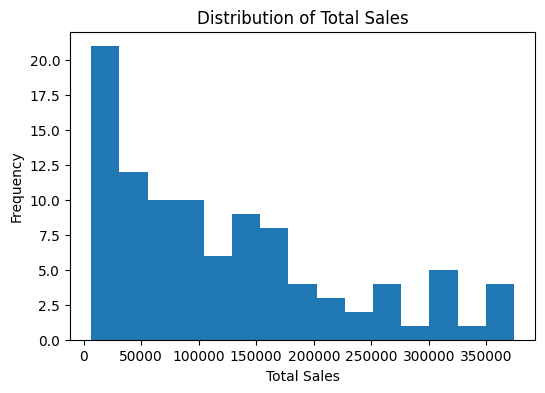


SHAPIRO-WILK TEST
Test Statistic: 0.8989262036779536
P-value: 1.2590767205714734e-06
Data is NOT normally distributed


In [7]:
# ---------------------- DATA DISTRIBUTION ANALYSIS ------------------------

#-----------------Create Histograms

# Histogram for Total Sales
plt.figure(figsize=(6,4))
plt.hist(sales_df['Total_Sales'], bins=15)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

#-----------------Test for Normal Distribution

# Shapiro-Wilk test checks normality
# H0 = Data is normally distributed
# H1 = Data is NOT normally distributed

shapiro_test = stats.shapiro(sales_df['Total_Sales'])

print('\nSHAPIRO-WILK TEST')
print('Test Statistic:', shapiro_test.statistic)
print('P-value:', shapiro_test.pvalue)

# Decision rule
if shapiro_test.pvalue > 0.05:
    print('Data appears normally distributed')
else:
    print('Data is NOT normally distributed')

**--------------------Correlation Analysis --------------------**

Calculate Pearson correlation, create heatmap


CORRELATION MATRIX
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


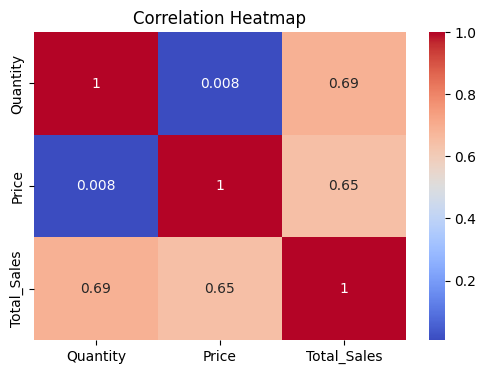

Correlation between Quantity and Total Sales: 0.69
Moderate positive correlation


In [8]:
# ---------------------- CORRELATION ANALYSIS -----------------------------

#-----------------------Pearson Correlation

# Correlation matrix for numerical columns
correlation_matrix = sales_numeric.corr(method='pearson')


print('\nCORRELATION MATRIX')
print(correlation_matrix)


#-----------------------Heatmap Visualization

# Create heatmap for correlations
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#----------------------Correlation Interpretation

# Correlation between Quantity and Total Sales
corr_value = sales_df['Quantity'].corr(sales_df['Total_Sales'])

print(f'Correlation between Quantity and Total Sales: {corr_value:.2f}')


# Interpretation
if corr_value > 0.7:
    print('Strong positive correlation')
elif corr_value > 0.3:
    print('Moderate positive correlation')
else:
    print('Weak correlation')

**----------------------HYPOTHESIS TESTING ---------------------------**

(In this We will perform 3 hypothesis tests.)

**Hypothesis Test 1: Independent T-Test**

Question: Is there a significant difference in Total Sales between East and West regions?

**Hypothesis Test 2: ANOVA Test**

Question: Do different products generate significantly different sales?

**Hypothesis Test 3: One-Sample T-Test**

Question: Is the average monthly charge greater than 100?

In [9]:
#-------------------Hypothesis Test 1: Independent T-Test

# Question: Is there a significant difference in Total Sales between East and West regions?

# Extracting sales data for East and West regions.
east_sales = sales_df[sales_df['Region'] == 'East']['Total_Sales']
west_sales = sales_df[sales_df['Region'] == 'West']['Total_Sales']

# Perform independent t-test
# H0 = No difference between means
# H1 = Significant difference exists

ttest_result = ttest_ind(east_sales, west_sales)

print('\nT-TEST RESULT')
print('T-statistic:', ttest_result.statistic)
print('P-value:', ttest_result.pvalue)


# Interpretation
if ttest_result.pvalue < 0.05:
    print('Reject H0 -> Significant difference exists')
else:
    print('Fail to reject H0 -> No significant difference')


#------------------- Hypothesis Test 2: ANOVA Test

# Question: Do different products generate significantly different sales?

# Group total sales by product
laptop_sales = sales_df[sales_df['Product'] == 'Laptop']['Total_Sales']
phone_sales = sales_df[sales_df['Product'] == 'Phone']['Total_Sales']
headphone_sales = sales_df[sales_df['Product'] == 'Headphones']['Total_Sales']


# Performing ANOVA
# H0 = All group means are equal
# H1 = At least one group mean is different

anova_result = f_oneway(laptop_sales, phone_sales, headphone_sales)

print('\nANOVA TEST RESULT')
print('F-statistic:', anova_result.statistic)
print('P-value:', anova_result.pvalue)

# Interpretation
if anova_result.pvalue < 0.05:
    print('Reject H0 -> Product sales differ significantly')
else:
    print('Fail to reject H0 -> No significant difference')


#------------------- Hypothesis Test 3: One-Sample T-Test

# Question: Is the average monthly charge greater than 100?

# Perform one-sample t-test
# H0 = Mean monthly charge = 100
# H1 = Mean monthly charge > 100

monthly_test = stats.ttest_1samp(churn_df['MonthlyCharges'], 100)

print('\nONE-SAMPLE T-TEST')
print('T-statistic:', monthly_test.statistic)
print('P-value:', monthly_test.pvalue)


# Interpretation
if monthly_test.pvalue < 0.05:
    print('Reject H0 -> Average monthly charge is significantly different')
else:
    print('Fail to reject H0 -> No significant difference')


T-TEST RESULT
T-statistic: 2.0202108796829767
P-value: 0.049619032636626016
Reject H0 -> Significant difference exists

ANOVA TEST RESULT
F-statistic: 1.9396625869436088
P-value: 0.1532892261448185
Fail to reject H0 -> No significant difference

ONE-SAMPLE T-TEST
T-statistic: 5.88630887332956
P-value: 7.254777576225509e-09
Reject H0 -> Average monthly charge is significantly different


**-------------------------CONFIDENCE INTERVALS ---------------------------**

Calculate 95% Confidence Interval for Average Sales and determine margin of errors

In [10]:
#--------------------- Calculate sample mean
mean_sales = sales_df['Total_Sales'].mean()

#---------------------- Standard error
std_error = stats.sem(sales_df['Total_Sales'])

#---------------------- 95% confidence interval
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales_df['Total_Sales']) - 1,
    loc=mean_sales,
    scale=std_error)

print('\n95% CONFIDENCE INTERVAL')
print('Average Sales:', round(mean_sales, 2))
print('Confidence Interval:', confidence_interval)

# --------------------- Margin of Error

# Margin of error calculation
margin_error = confidence_interval[1] - mean_sales

print('Margin of Error:', round(margin_error, 2))


95% CONFIDENCE INTERVAL
Average Sales: 123650.48
Confidence Interval: (np.float64(103776.34767158539), np.float64(143524.6123284146))
Margin of Error: 19874.13


**--------------------- Regression Analysis ----------------------**

 Performing linear regression and calculate R-squared

 R-squared tells how much variation is explained by the model.
Closer to 1 = better model.



LINEAR REGRESSION RESULTS
Intercept: -3638.741480185796
Coefficient: 26629.544242716693
R-squared: 0.47349189833176386


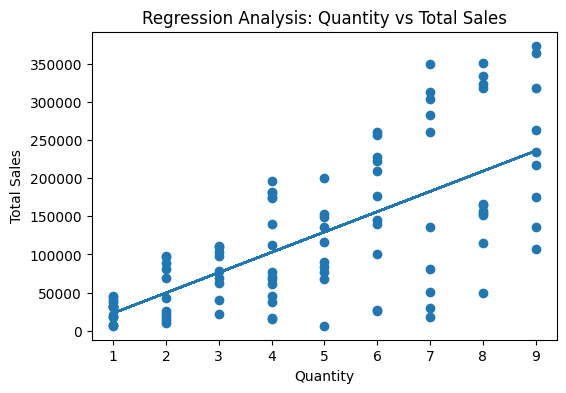

In [11]:
# ----------------------Linear Regression

# We will predict Total Sales using Quantity.

# Independent variable (must be 2D)
X = sales_df[['Quantity']]

# Dependent variable
y = sales_df['Total_Sales']

# Create regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Make predictions
predictions = model.predict(X)

# R-squared score
r2 = r2_score(y, predictions)


print('\nLINEAR REGRESSION RESULTS')
print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])
print('R-squared:', r2)


# --------------------Regression Visualization

# Scatter plot with regression line

plt.figure(figsize=(6,4))
plt.scatter(X, y)
plt.plot(X, predictions)
plt.title('Regression Analysis: Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

**------------------------ Business Insights ------------------------**

Translate findings, creating actionable recommendations

In [12]:
# ----------------Insights

print('\nSTATISTICAL ANALYSIS REPORT')
print('--------------------------------')

# Average sales insight
print(f'Average Sales: {mean_sales:.2f}')

# Correlation insight
print(f'Correlation (Quantity vs Total Sales): {corr_value:.2f}')

# Regression insight
print(f'Regression R-squared: {r2:.2f}')

# T-test insight
if ttest_result.pvalue < 0.05:
    print('Regional sales differences are statistically significant.')
else:
    print('Regional sales differences are not statistically significant.')

# ANOVA insight
if anova_result.pvalue < 0.05:
    print('Different products perform differently in terms of sales.')
else:
    print('Product sales performance is statistically similar.')


STATISTICAL ANALYSIS REPORT
--------------------------------
Average Sales: 123650.48
Correlation (Quantity vs Total Sales): 0.69
Regression R-squared: 0.47
Regional sales differences are statistically significant.
Product sales performance is statistically similar.


**-------------------------------   Final Business Recommendations ---------------------------------**

1. ***Focus on High Performing Products:*** If ANOVA shows significant differences, invest more marketing budget in top-performing products.

2. ***Improve Sales Strategy by Region:*** If regional differences are significant, optimize inventory and promotions region-wise.

3. ***Use Quantity Forecasting:*** Regression analysis shows how sales increase with quantity. This can help in demand forecasting.

4. ***Monitor Customer Charges:*** If customer monthly charges are significantly high, review pricing strategies to reduce churn risk.